In [60]:
from Utils.dataset_utils import DatasetUtils
import pandas as pd
from collections import Counter

In [61]:
train_dataset, _ = DatasetUtils.download_celeba(
    train_csv="original_merged",
    base_path="../../../data/celeba",
    debug=True,
)

In [62]:
train_dataset.indexes

range(0, 202599)

In [63]:
df = pd.read_csv("../../../data/celeba/original_merged.csv")

In [64]:
targets = [1 if item == 1 else 0 for item in df["Smiling"]]

sensitive_values = [1 if item == 1 else 0 for item in df["Male"]]

In [65]:
df.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young,split,Target
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,1,-1,1,-1,1,-1,-1,1,0.137514,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,-1,-1,-1,-1,-1,-1,1,-0.432273,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,1,-1,-1,-1,-1,-1,1,1.841473,0
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,1,-1,1,-1,1,1,-1,1,-0.080797,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,1,-1,-1,1,1.045482,1


In [66]:
df.keys()

Index(['image_id', '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',
       'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose',
       'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows',
       'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair',
       'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open',
       'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin',
       'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns',
       'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings',
       'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace',
       'Wearing_Necktie', 'Young', 'split', 'Target'],
      dtype='object')

In [67]:
df["Attractive"].value_counts()

 1    103833
-1     98766
Name: Attractive, dtype: int64

In [68]:
df_attractive = df[df["Attractive"] == 1]
df_not_attractive = df[df["Attractive"] == -1]

In [69]:
df_attractive.shape

(103833, 43)

In [70]:
df_not_attractive.shape

(98766, 43)

In [71]:
targets = [1 if item == 1 else 0 for item in df_attractive["Smiling"]]

sensitive_values = [1 if item == 1 else 0 for item in df_attractive["Male"]]

sensitive_target = [(s, t) for t, s in zip(targets, sensitive_values)]
Counter(sensitive_target)

Counter({(0, 1): 46168, (0, 0): 34086, (1, 0): 12210, (1, 1): 11369})

In [72]:
# drop 50% of the samples where the target is 1 and the sensitive value is 1
dropped_indexes_1 = (
    df_attractive[(df_attractive["Smiling"] == 1) & (df_attractive["Male"] == -1)].sample(frac=0.3).index
)

dropped_indexes_2 = (
    df_attractive[(df_attractive["Smiling"] == -1) & (df_attractive["Male"] == -1)].sample(frac=0.3).index
)

df_dropped_1 = df_attractive.loc[dropped_indexes_1]
df_dropped_2 = df_attractive.loc[dropped_indexes_2]

df_attractive = df_attractive.drop(dropped_indexes_1)
df_attractive = df_attractive.drop(dropped_indexes_2)


df_attractive.shape

(79757, 43)

In [73]:
df_not_attractive = pd.concat([df_not_attractive, df_dropped_1])
df_not_attractive.shape

(112616, 43)

In [74]:
targets = [1 if item == 1 else 0 for item in df_not_attractive["Smiling"]]

sensitive_values = [1 if item == 1 else 0 for item in df_not_attractive["Male"]]

sensitive_target = [(s, t) for t, s in zip(targets, sensitive_values)]
Counter(sensitive_target)

Counter({(0, 1): 31553, (1, 0): 38426, (1, 1): 22429, (0, 0): 20208})

In [75]:
# # drop 50% of the samples where the target is 1 and the sensitive value is 1
# dropped_indexes_1 = (
#     df_attractive[(df_attractive["Smiling"] == 1) & (df_attractive["Male"] == -1)]
#     .sample(frac=0.7)
#     .index
# )


# df_dropped_1 = df_attractive.loc[dropped_indexes_1]

# df_attractive = df_attractive.drop(dropped_indexes_1)


# df_attractive.shape

In [76]:
# df_attractive.to_csv("../../../data/celeba/df_attractive_new_test.csv")
# df_not_attractive.to_csv("../../../data/celeba/df_not_attractive_new_test.csv")

In [77]:
# df_attractive = pd.read_csv("../../../data/celeba/df_attractive.csv")
# df_not_attractive = pd.read_csv("../../../data/celeba/df_not_attractive.csv")

In [78]:
# # drop 50% of the samples where the target is 1 and the sensitive value is 1
# dropped_indexes_1 = (
#     df_attractive[(df_attractive["Smiling"] == 1) & (df_attractive["Male"] == -1)]
#     .sample(frac=0.6)
#     .index
# )


# df_dropped_1 = df_attractive.loc[dropped_indexes_1]

# df_attractive = df_attractive.drop(dropped_indexes_1)


# df_attractive.shape

In [79]:
# df_attractive.to_csv("../../../data/celeba/df_attractive_new_test_3.csv")
# df_not_attractive.to_csv("../../../data/celeba/df_not_attractive_new_test.csv")

# Test New Distribution

In [116]:
train_dataset_attractive, _ = DatasetUtils.download_celeba(
    train_csv="df_attractive_new_test_2",
    base_path="../../../data/celeba",
    debug=True,
)

In [117]:
len(train_dataset_attractive.targets)

57134

In [118]:
from Utils.utils import Utils
from Utils.train_parameters import TrainParameters

In [119]:
train_parameters = TrainParameters(
    epochs=10,
    device="cuda",
    batch_size=64,
    seed=1,
    metric="disparity",
    optimizer="adam",
)

In [120]:
train_path_attractive = Utils.prepare_dataset_for_FL(
    dataset=train_dataset_attractive,
    dataset_name="celeba",
    base_path="../../../data/",
)

Generating unified dataset
Data Correctly downloaded


Partitioning the dataset
Counter({0: 36070, 1: 21064})
SPLITTING THE DATASET USING the representative partitioning
Mean of disparity 0.19312283765004593 - std 0.04746276727929347
Mean of disparity 0.19312283765004595 - std 0.04746276727929347
[62, 67, 61, 74, 65, 73, 68, 71, 63, 65, 59, 61, 61, 83, 67, 59, 64, 65, 67, 81, 61, 68, 62, 74, 72, 61, 61, 57, 68, 72, 68, 79, 64, 59, 67, 62, 64, 64, 64, 61, 67, 61, 65, 54, 73, 68, 55, 58, 59, 52, 57, 59, 74, 63, 62, 51, 55, 74, 63, 67, 61, 74, 70, 47, 53, 61, 62, 60, 52, 61, 66, 65, 69, 79, 72, 59, 63, 44, 74, 59, 68, 70, 59, 63, 70, 60, 62, 55, 68, 63, 66, 73, 67, 69, 68, 76, 73, 69, 62, 56, 67, 64, 63, 60, 64, 74, 58, 60, 70, 56, 62, 70, 69, 50, 67, 82, 51, 60, 68, 60, 54, 60, 75, 63, 82, 67, 56, 61, 67, 65, 53, 72, 62, 69, 56, 59, 65, 61, 67, 60, 67, 77, 62, 65, 52, 57, 70, 44, 57, 71]
[154, 146, 154, 156, 161, 159, 156, 148, 174, 147, 162, 157, 149, 145, 144, 148, 158, 158, 157, 144, 163, 152, 148, 143, 147, 171, 174, 147, 158, 152, 165, 

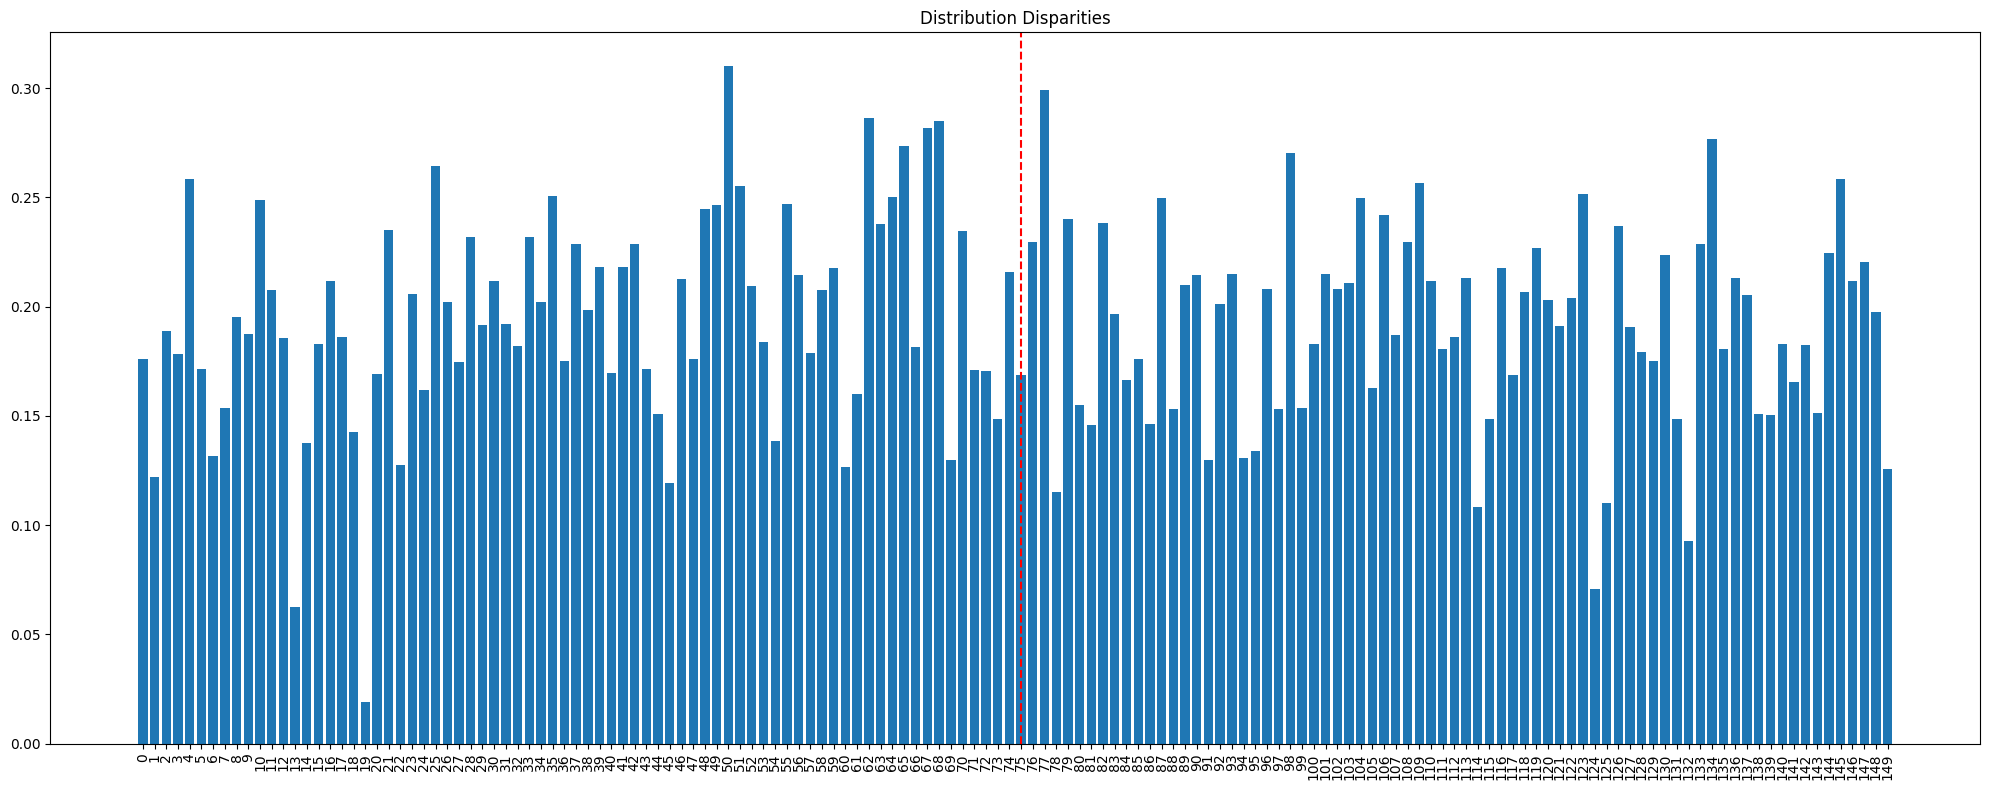

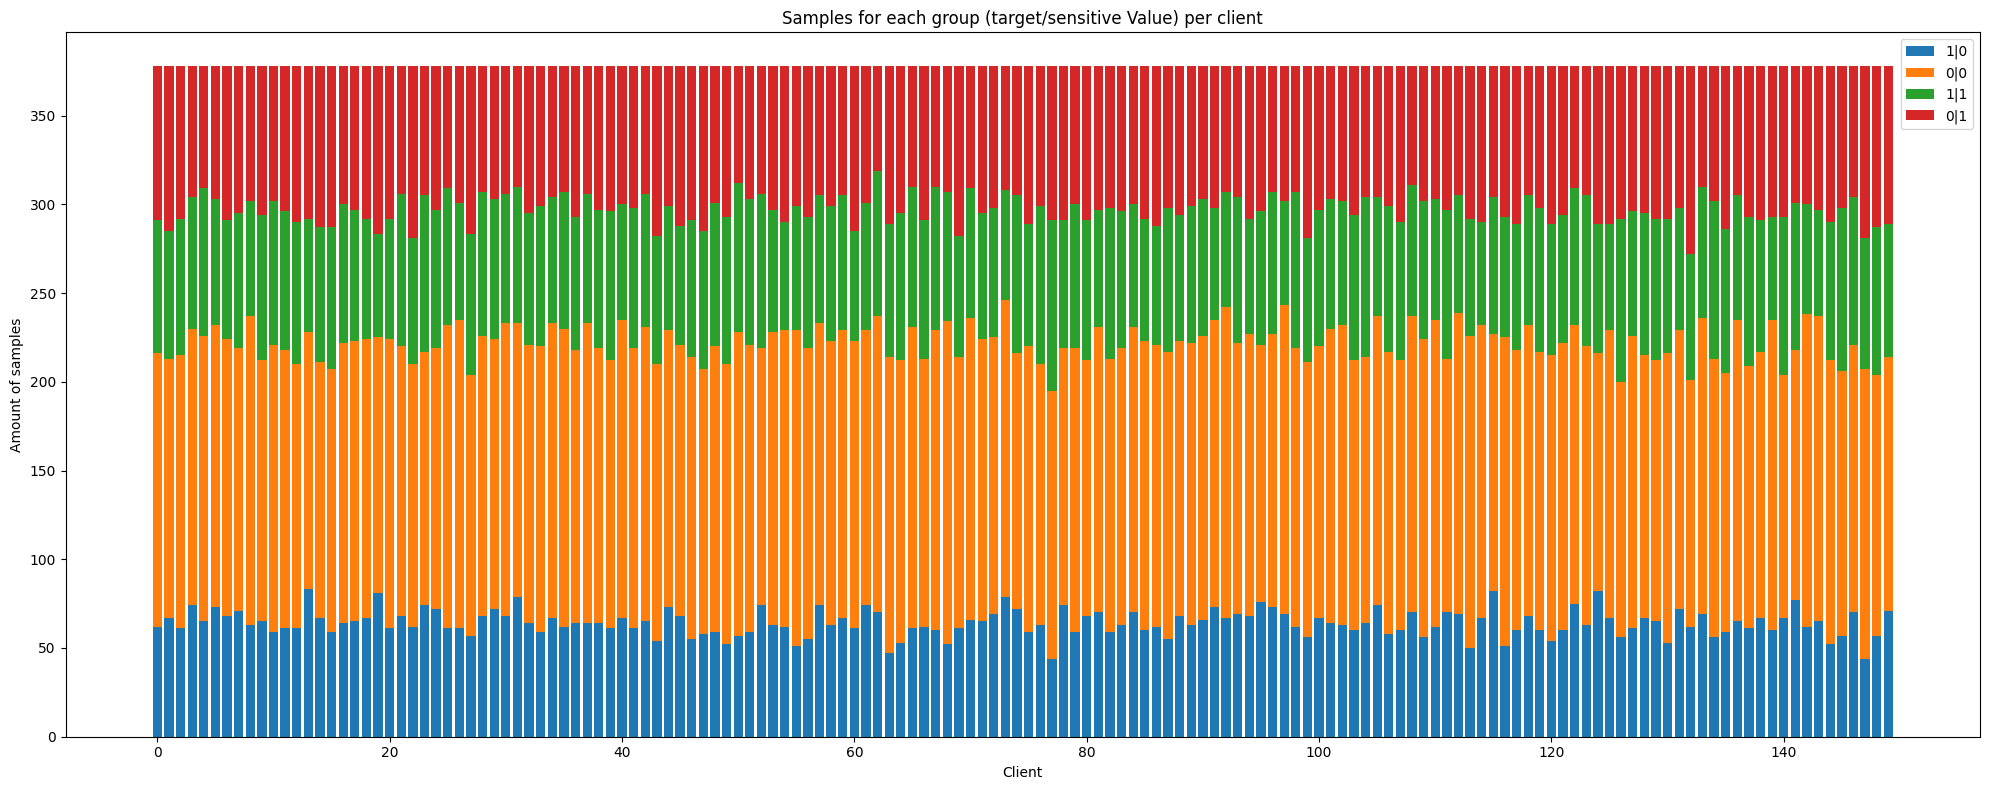

In [121]:
# Attractive Partitioning

# 103833/150
fed_dir = Utils.do_fl_partitioning(
    train_path_attractive,
    pool_size=150,
    num_classes=2,
    val_ratio=0,
    partition_type="representative",
    train_parameters=train_parameters,
    group_to_reduce=(1, 1),
    group_to_increment=(0, 1),
    number_of_samples_per_node=378,
    ratio_unfair_nodes=0.5,
    ratio_unfairness=(0, 0),
    splitted_data_dir="federated",
)

In [122]:
train_dataset_NOT_attractive, _ = DatasetUtils.download_celeba(
    train_csv="df_not_attractive_new_test",
    base_path="../../../data/celeba",
    debug=True,
)

len(train_dataset_NOT_attractive.targets)

112616

In [123]:
train_path_NOT_attractive = Utils.prepare_dataset_for_FL(
    dataset=train_dataset_NOT_attractive,
    dataset_name="celeba",
    base_path="../../../data/",
)

Generating unified dataset
Data Correctly downloaded


Partitioning the dataset
Counter({0: 58634, 1: 53982})
SPLITTING THE DATASET USING the representative partitioning
Mean of disparity 0.24098776538922959 - std 0.03368669358385496
Mean of disparity 0.2409877653892296 - std 0.03368669358385496
[211, 196, 210, 204, 204, 225, 210, 205, 215, 181, 209, 220, 204, 209, 206, 197, 218, 203, 228, 222, 210, 227, 211, 225, 217, 208, 209, 195, 198, 224, 192, 199, 224, 224, 214, 192, 219, 218, 230, 193, 207, 193, 205, 208, 233, 204, 211, 232, 197, 202, 220, 225, 190, 221, 194, 189, 207, 213, 203, 210, 220, 200, 220, 182, 210, 204, 213, 222, 228, 215, 187, 219, 212, 220, 213, 237, 184, 218, 205, 211, 199, 198, 188, 214, 205, 182, 215, 191, 219, 223, 207, 228, 215, 219, 194, 228, 218, 210, 210, 206, 234, 199, 185, 198, 212, 187, 204, 216, 214, 219, 216, 220, 201, 185, 214, 207, 218, 214, 212, 227, 223, 199, 204, 204, 214, 208, 224, 223, 194, 192, 224, 210, 194, 213, 200, 217, 211, 211, 207, 205, 245, 213, 219, 221, 227, 201, 224, 225, 194, 222]
[139, 1

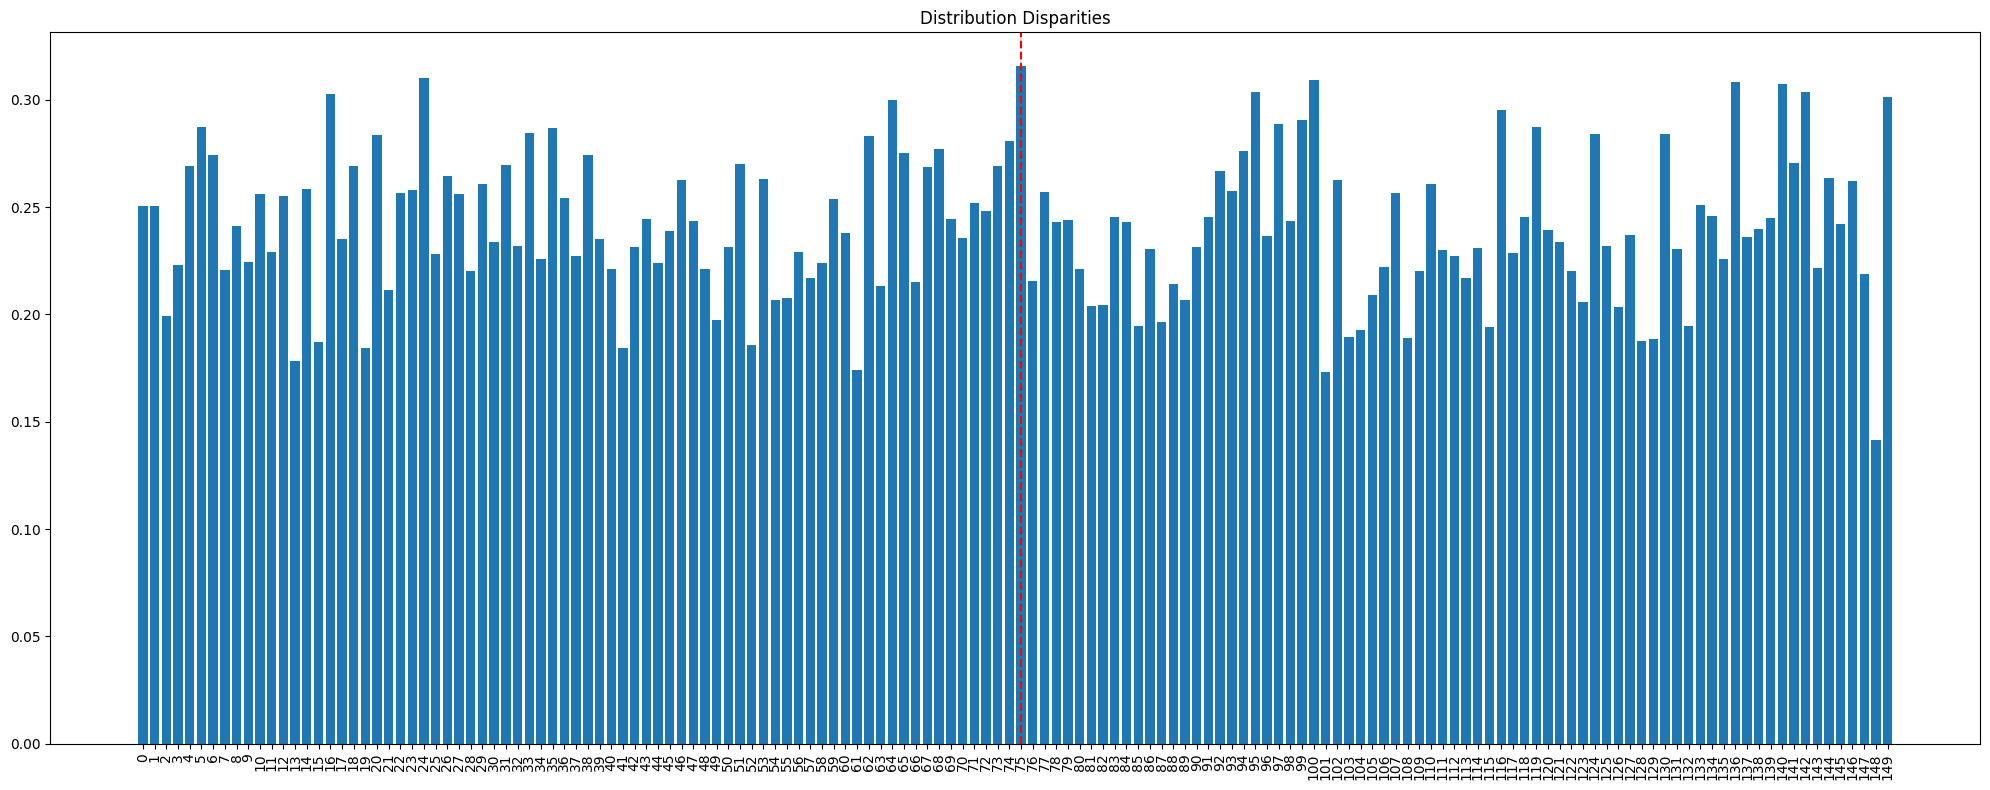

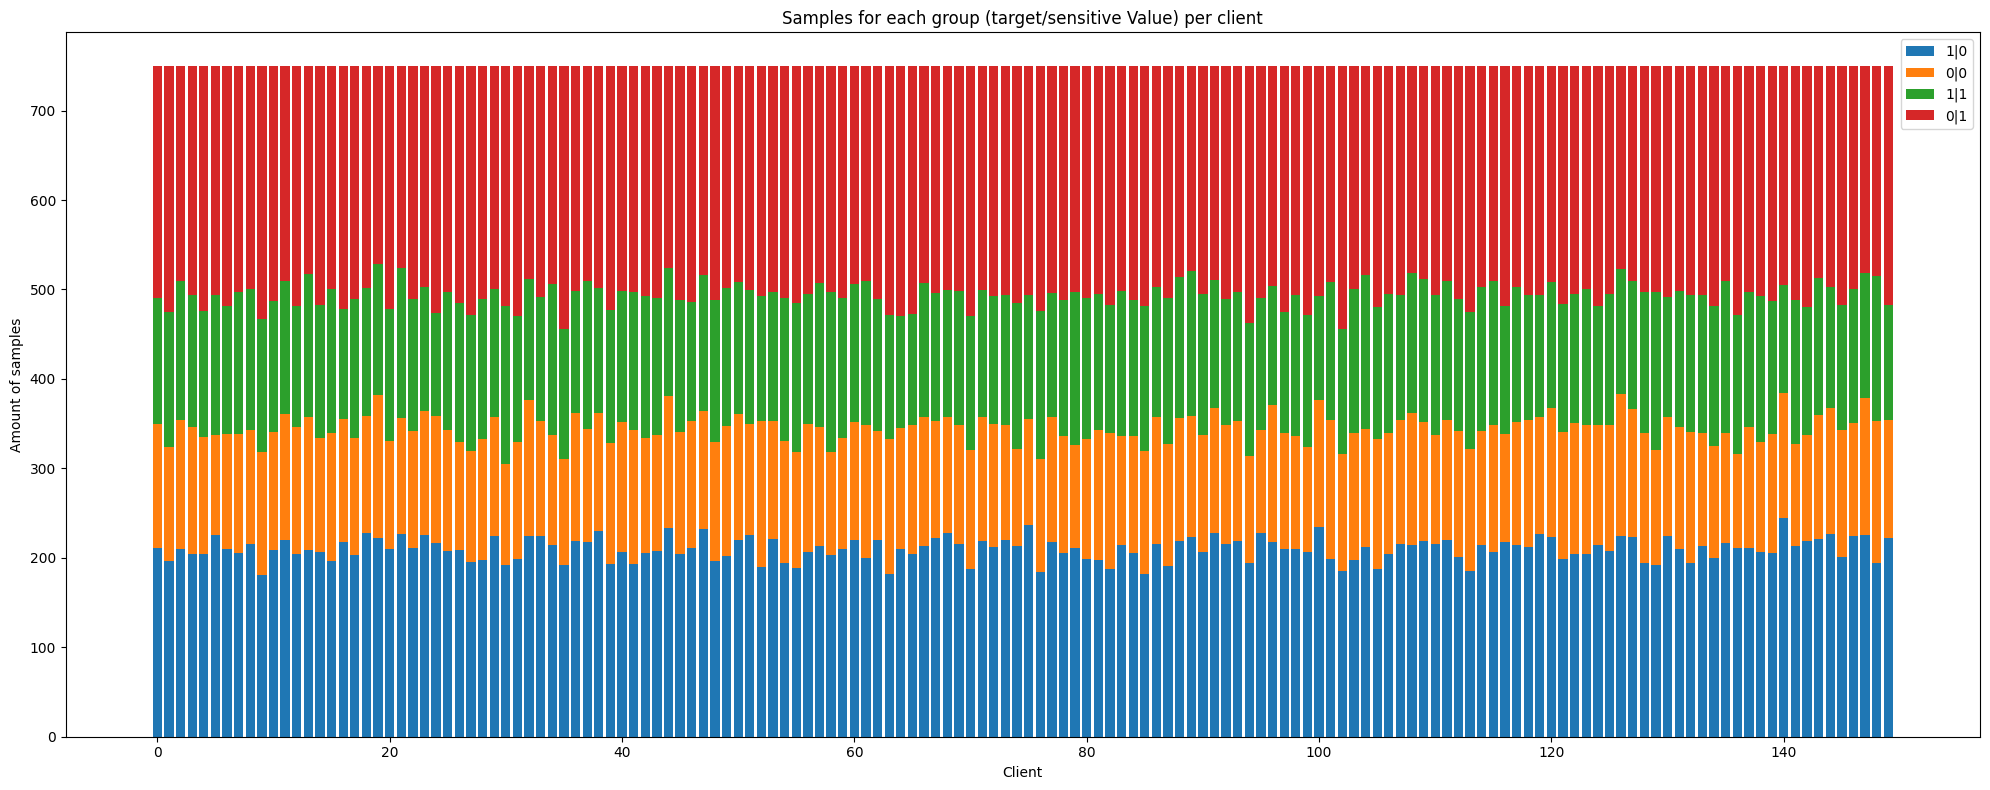

In [124]:
# Attractive Partitioning
fed_dir = Utils.do_fl_partitioning(
    train_path_NOT_attractive,
    pool_size=150,
    num_classes=2,
    val_ratio=0,
    partition_type="representative",
    train_parameters=train_parameters,
    group_to_reduce=(1, 1),
    group_to_increment=(0, 1),
    number_of_samples_per_node=750,
    ratio_unfair_nodes=0.5,
    ratio_unfairness=(0, 0),
    splitted_data_dir="federated",
)